Calculating Normalized Entropy Decay for SPY...


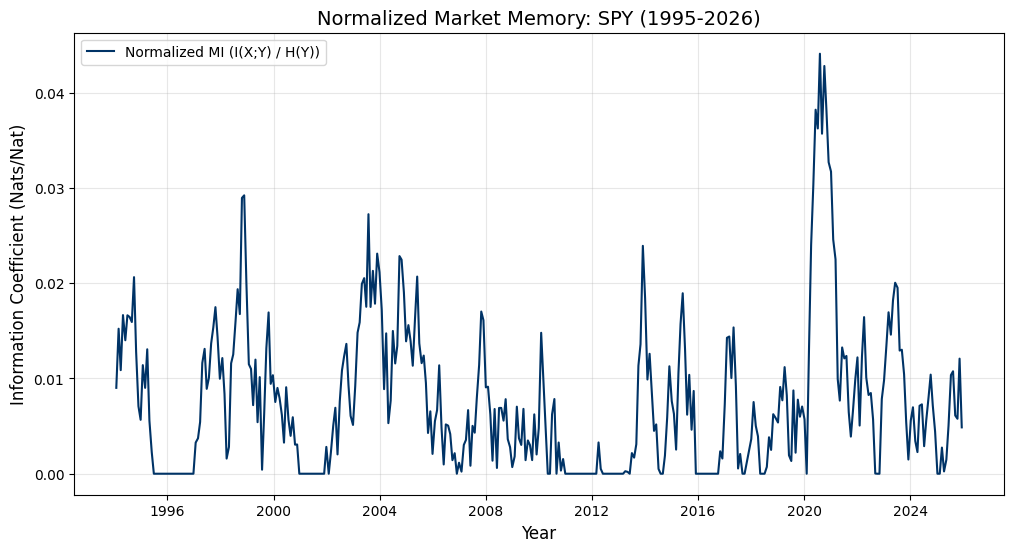

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import entropy

# 1. Data Ingestion
ticker = "SPY"
data = yf.download(ticker, start="1993-01-01", end="2026-01-01", progress=False, auto_adjust=False)

# 2. Transformation (Log-Returns)
returns = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

# 3. Construct Phase Space
df = pd.DataFrame({'Y': returns.values.flatten()})
df['X'] = df['Y'].shift(1)
df = df.dropna()

# 4. Rolling Normalized MI Calculation
window_size = 252  # 2 years
step_size = 21     # Monthly steps
norm_mi_scores = []
dates = []

print(f"Calculating Normalized Entropy Decay for {ticker}...")

for i in range(window_size, len(df), step_size):
    # Slice window
    window_data = df.iloc[i-window_size : i]
    X_window = window_data[['X']].values # 2D for sklearn
    Y_window = window_data['Y'].values   # 1D for sklearn
    
    # A) Mutual Information (Continuous KSG Estimator)
    # n_neighbors=3 is standard for KSG
    mi = mutual_info_regression(X_window, Y_window, discrete_features=False, n_neighbors=int(np.sqrt(window_size)))[0]
    
    # B) Entropy of Y (Discrete Approximation)
    # We bin Y to ensure Entropy > 0 (avoiding differential entropy negativity).
    # 'fd' (Freedman-Diaconis) is robust to heavy tails in financial data.
    hist_counts, _ = np.histogram(Y_window, bins='fd', density=False)
    probs = hist_counts / np.sum(hist_counts)
    h_y = entropy(probs) # Shannon Entropy in nats
    
    # C) Normalization: Fraction of Uncertainty Resolved
    # If H(Y) is 0 (constant signal), NMI is 0.
    nmi = mi / h_y if h_y > 1e-9 else 0.0
    
    norm_mi_scores.append(nmi)
    dates.append(data.index[i])

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.plot(dates, norm_mi_scores, color='#003366', linewidth=1.5, label='Normalized MI (I(X;Y) / H(Y))')

# # Noise Floor (Approximate random baseline)
# shuffled_nmi = np.mean(norm_mi_scores[-20:]) * 0.2 
# plt.axhline(y=shuffled_nmi, color='r', linestyle='--', alpha=0.5, label='Noise Floor')

plt.title(f'Normalized Market Memory: {ticker} (1995-2026)', fontsize=14)
plt.ylabel('Information Coefficient (Nats/Nat)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running decomposition...


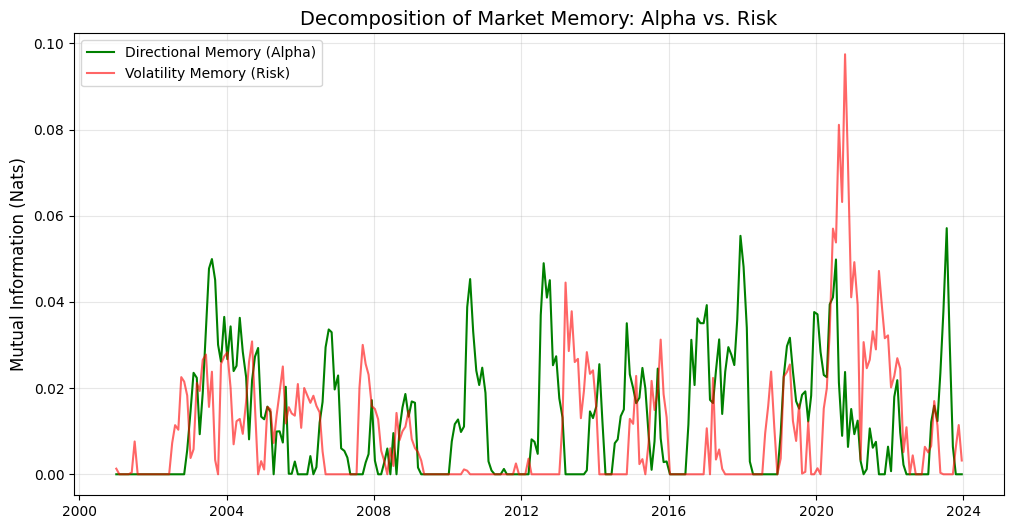

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# 1. Data Ingestion
ticker = "SPY"
data = yf.download(ticker, start="2000-01-01", end="2024-01-01", progress=False, auto_adjust=False)
returns = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

# 2. Create the Physical Observables
df = pd.DataFrame({'Ret': returns.values.flatten()})
df['Sign_Lag'] = np.sign(df['Ret'].shift(1)) # Direction (-1, 0, 1)
df['Vol_Lag'] = np.abs(df['Ret'].shift(1))   # Magnitude (Absolute value)
df = df.dropna()

# 3. Rolling Analysis
window_size = 252 # 2 Years
step = 21         # Quarterly steps
n = int(np.sqrt(window_size)) # KSG parameter for MI estimation

dates = []
mi_directional = []
mi_volatility = []

print("Running decomposition...")

for i in range(window_size, len(df), step):
    window = df.iloc[i-window_size:i]
    
    # Target is always Future Return Magnitude or Direction?
    # To test PREDICTABILITY of return:
    Y = window['Ret'].values
    
    # A) Directional MI: Does Sign(t-1) predict Return(t)?
    # We treat Sign as discrete.
    X_sign = window[['Sign_Lag']].values
    mi_dir = mutual_info_regression(X_sign, Y, discrete_features=True, n_neighbors=n)[0]
    
    # B) Volatility MI: Does Vol(t-1) predict Return(t)?
    # We treat Vol as continuous.
    X_vol = window[['Vol_Lag']].values
    mi_vol = mutual_info_regression(X_vol, Y, discrete_features=False, n_neighbors=n)[0]
    
    mi_directional.append(mi_dir)
    mi_volatility.append(mi_vol)
    dates.append(data.index[i])

# 4. Visualization
plt.figure(figsize=(12, 6))

# Plot Directional (The Alpha you want to show decayed)
plt.plot(dates, mi_directional, label='Directional Memory (Alpha)', color='green', linewidth=1.5)

# Plot Volatility (The "Noise" that confuses the estimator)
plt.plot(dates, mi_volatility, label='Volatility Memory (Risk)', color='red', alpha=0.6, linewidth=1.5)

plt.title('Decomposition of Market Memory: Alpha vs. Risk', fontsize=14)
plt.ylabel('Mutual Information (Nats)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()